# Feature - Development Classification | Exploratory Data Analysis

## Import Relevant Libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import kagglehub
import torch
import cv2
from IPython.core.pylabtools import figsize
from scipy.spatial import distance
from torchvision.datasets import ImageFolder
from torchvision import transforms
sns.set_style("whitegrid")

## Load Feature Engineered Dataset

In [52]:
csv_path = "../data/drawing_features.csv"
df = pd.read_csv(csv_path)

## Exploring the features of the dataframe

In [53]:
df.head()

,filename,dataset_source,label_name,fill_ratio,avg_pressure,warm_color_ratio,blob_count,centrality
0,101-1A-1240-M-H.jpg,Train,Happiness,0.1436,110.57,0.53,204,0.7977
1,101-1A-1298-M-H.jpg,Train,Happiness,0.0977,112.21,0.39,111,0.8133
2,101-1A-141-M-H.jpg,Train,Happiness,0.0551,138.85,0.50,88,0.6214
3,101-1A-1543-M-H.jpg,Train,Happiness,0.0663,106.86,0.57,85,0.9383
4,101-1A-331-F-H.jpg,Train,Happiness,0.1426,99.45,0.50,71,0.7955


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10860 entries, 0 to 10859
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          10860 non-null  object 
 1   dataset_source    10860 non-null  object 
 2   label_name        10860 non-null  object 
 3   fill_ratio        10860 non-null  float64
 4   avg_pressure      10860 non-null  float64
 5   warm_color_ratio  10860 non-null  float64
 6   blob_count        10860 non-null  int64  
 7   centrality        10860 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 678.9+ KB


In [55]:
df.describe(include='all')

,filename,dataset_source,label_name,fill_ratio,avg_pressure,warm_color_ratio,blob_count,centrality
count,10860,10860,10860,10860.000000,10860.000000,10860.000000,10860.000000,10860.000000
unique,10860,2,2,NaN,NaN,NaN,NaN,NaN
top,101-1A-1240-M-H.jpg,Train,Happiness,NaN,NaN,NaN,NaN,NaN
freq,1,9228,5430,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.189448,117.737529,0.483445,143.130110,0.805740
std,NaN,NaN,NaN,0.165124,26.086825,0.294263,197.559285,0.119604
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,0.079300,99.420000,0.240000,32.000000,0.729400
50%,NaN,NaN,NaN,0.146100,114.590000,0.450000,80.000000,0.823550
75%,NaN,NaN,NaN,0.246400,132.742500,0.710000,176.000000,0.899000


In [56]:
df['label_name'].value_counts()

label_name
Happiness    5430
Sadness      5430
Name: count, dtype: int64

In [57]:
df['dataset_source'].value_counts()

dataset_source
Train    9228
Test     1632
Name: count, dtype: int64

In [58]:
df.isna().sum()

filename            0
dataset_source      0
label_name          0
fill_ratio          0
avg_pressure        0
warm_color_ratio    0
blob_count          0
centrality          0
dtype: int64

## Exploratory Data Analysis 

Features to Extract from the images


*   **Fill ratio** - (Pixels with drawing) / (Total Pixels)

tiny figures in the corner (timidity/anxiety) or fill the whole page (confidence/impulsivity)

*   **Pressure/Stroke Thickness** - Average pixel intensity of the edges.

Heavy, dark lines often indicate high energy or aggression. Faint, sketchy lines can indicate hesitation or low energy.



*   **Color Palette (Warm vs. Cool)** - Dominant Hue analysis.

Predominance of Red/Orange (Warm) vs. Blue/Green (Cool) vs. Black/White.


*   **"Blob" Count (Object Individuation)** - Number of closed contours.

Younger children draw disconnected items. Older children connect them into a scene.


*   Centroid Logic (Centrality):

Is the main subject in the center (egocentric) or spread out?

### Exploring Fill Ratio

<Axes: xlabel='fill_ratio', ylabel='Count'>

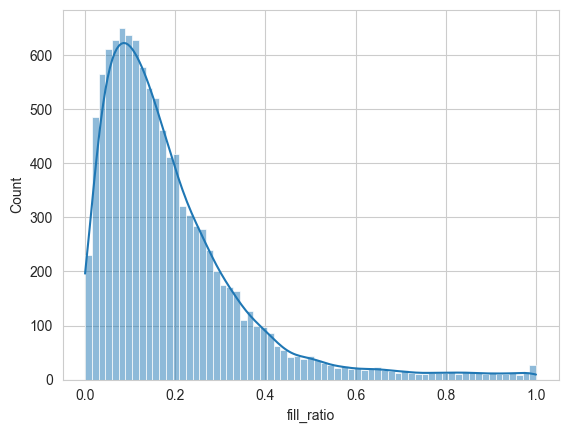

In [59]:
sns.histplot(df['fill_ratio'], kde=True)

<Axes: xlabel='label_name', ylabel='fill_ratio'>

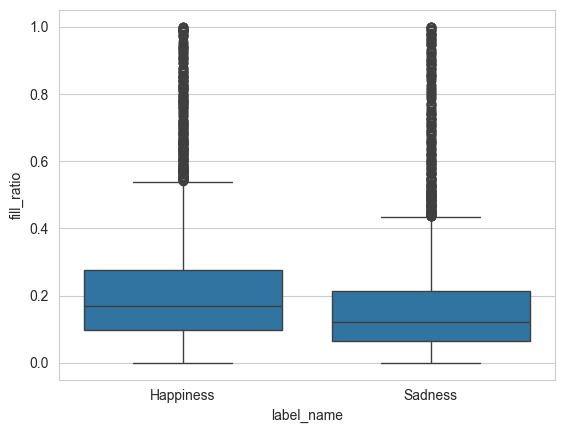

In [60]:
sns.boxplot(data=df, x='label_name', y='fill_ratio')

Fill ratio in this dataset is strongly left-skewed, with most drawings occupying only 10-20% of the page. Happy-labelled drawings tend to use slightly more space than sad-labelled ones, reflected by a higher mean (~0.18 vs ~0.10) and more high-end outliers. 
This suggests that happiness is associated with more expensive, expressive drawings, whereas sadness correlate with more constrained spatial use.

### Exploring Average Pressure

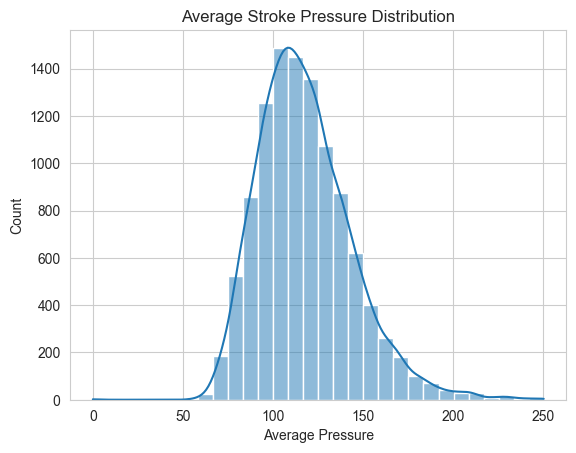

In [61]:
sns.histplot(df['avg_pressure'], kde=True, bins=30)
plt.title("Average Stroke Pressure Distribution")
plt.xlabel("Average Pressure")
plt.show()

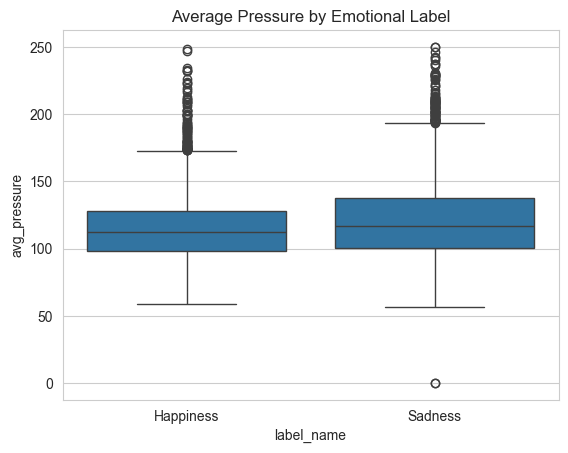

In [62]:
sns.boxplot(data=df, x='label_name', y='avg_pressure')
plt.title("Average Pressure by Emotional Label")
plt.show()

Stroke pressure is generally moderate for most children, with slight variability. While happiness does not drastically increase pressure, sadness occasionally produce very heavy strokes, perhaps reflecting moments of tension or emotional intensity. Overall, pressure indicates energy or emotional engagement, but it is not as strongly correlated with emotion label as fill ratio

### Exploring the color pallet (Warm vs Cool Color Ratio)

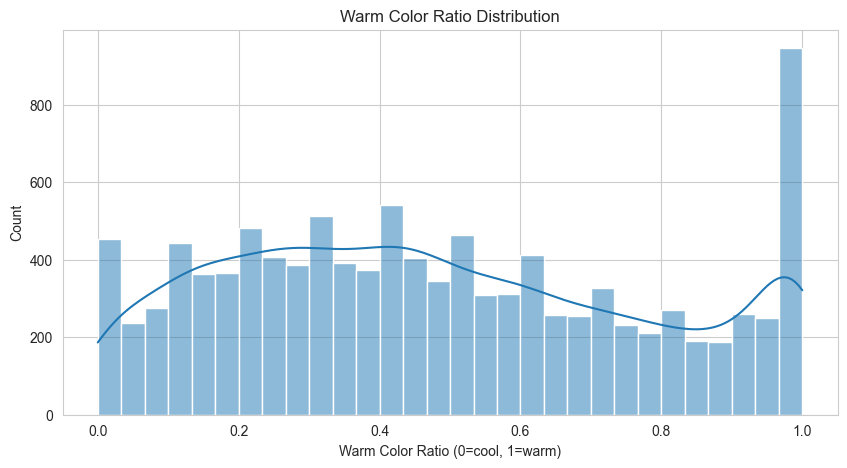

In [63]:
plt.figure(figsize=(10, 5))
sns.histplot(df['warm_color_ratio'], bins=30, kde=True)
plt.title("Warm Color Ratio Distribution")
plt.xlabel("Warm Color Ratio (0=cool, 1=warm)")
plt.ylabel("Count")
plt.show()

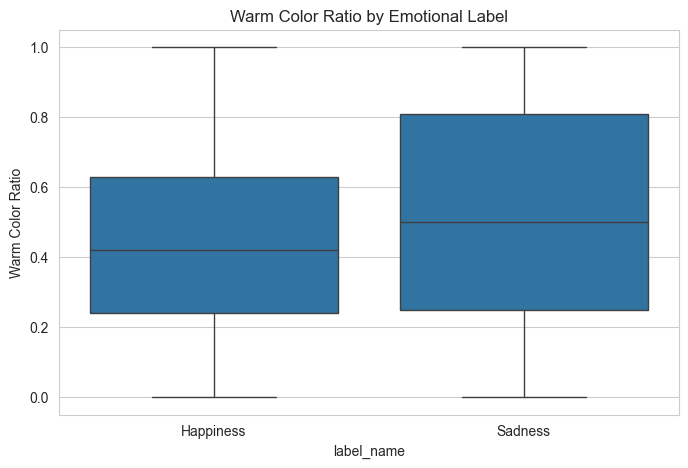

In [64]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label_name', y='warm_color_ratio')
plt.title("Warm Color Ratio by Emotional Label")
plt.ylabel("Warm Color Ratio")
plt.show()

In [65]:
df.groupby('label_name')['warm_color_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Happiness,5430.0,0.448477,0.264307,0.0,0.24,0.42,0.63,1.0
Sadness,5430.0,0.518413,0.317638,0.0,0.25,0.50,0.81,1.0


From the histogram it can be seen that most drawings have low to moderate warm colors (0 - 0.6). Although there is a big spike at 1.0, which implies that it is purely warm. This could be because some children only use warm colors (red, orange, yellow). They are likely very expressive, energetic, or strongly emotional drawings. There irregular bars indicates high variability in color usage, this is because not all kids follow a typical color palette. 

From the boxplot, the sad drawings are slightly more "warm" on average. This implies that use of intense warm colors to express sadness (eg: red, brown, dark orange for tension/anger). Sad drawings have higher standard deviation (0.318 cs 0.264), as it could be because of the more extreme color choices.

### Exploring Blob Count (The number of seperated closed contours)

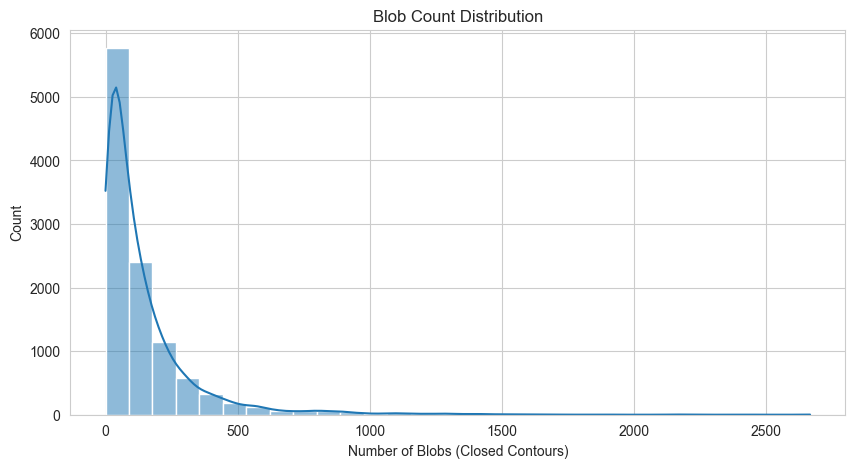

In [66]:
plt.figure(figsize=(10, 5))
sns.histplot(df['blob_count'], bins=30, kde=True)
plt.title("Blob Count Distribution")
plt.xlabel("Number of Blobs (Closed Contours)")
plt.ylabel("Count")
plt.show()

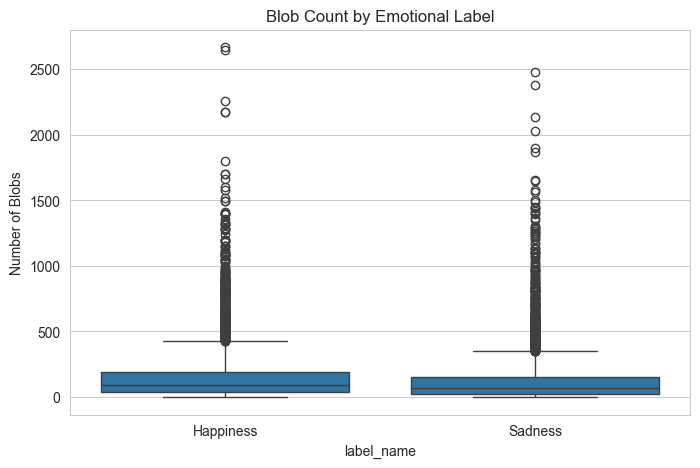

In [67]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label_name', y='blob_count')
plt.title("Blob Count by Emotional Label")
plt.ylabel("Number of Blobs")
plt.show()

In [68]:
df.groupby('label_name')['blob_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Happiness,5430.0,158.264457,206.078279,1.0,39.0,93.0,195.0,2668.0
Sadness,5430.0,127.995764,187.456909,0.0,25.0,69.0,155.0,2475.0


Most children draws a small number of distinct objects. A few drawings have many tiny blobs - likely highly detailed or fragmented drawings. Extreme counts are rare. 

The young children, usually draws simpler scenes or children drawing a single main subject. Meanwhile, the older children are higher detailed-oriented. Their drawings have a higher blob count

Happy drawings have a slightly higher blob count, since children might draw more details, more object when they are happy. While sad drawings might have a lower blob count due to their lower motivation, attention or energy. The extreme values are outliers, they might indicate, that very energetic or scribbling as emotional behavior 

### Exploring Centrality

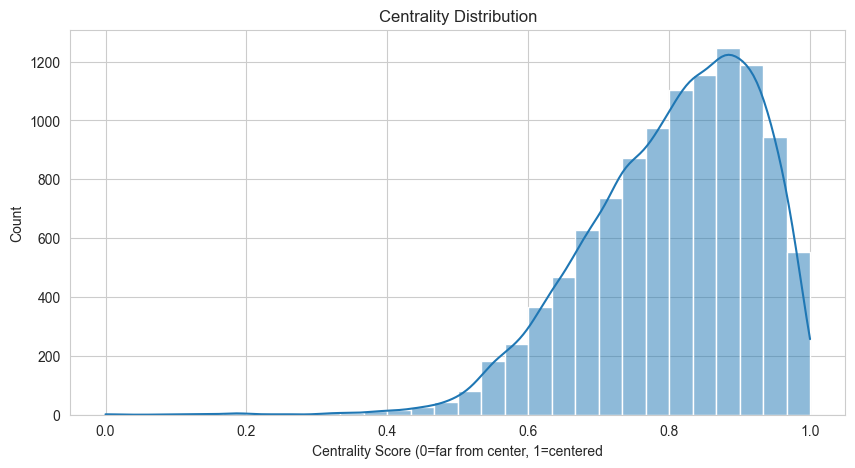

In [69]:
plt.figure(figsize=(10, 5))
sns.histplot(df['centrality'], bins=30, kde=True)
plt.title("Centrality Distribution")
plt.xlabel("Centrality Score (0=far from center, 1=centered")
plt.ylabel("Count")
plt.show()

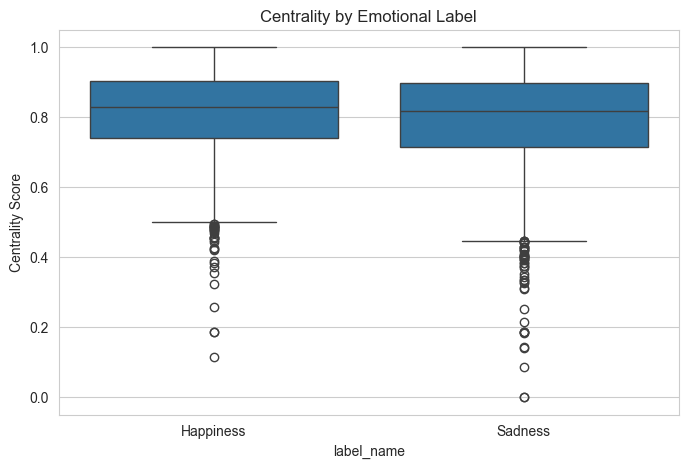

In [70]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label_name', y='centrality')
plt.title("Centrality by Emotional Label")
plt.ylabel("Centrality Score")
plt.show()

In [71]:
df.groupby('label_name')['centrality'].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Happiness,5430.0,0.814092,0.112043,0.1136,0.739525,0.8293,0.9020,1.0
Sadness,5430.0,0.797387,0.126174,0.0000,0.715550,0.8175,0.8961,1.0


Most drawings have high centrality, the main subject is placed near the center. Very few drawings place the subject far from the center. Children generally draw egocentrically, focusing attention in the middle of the page

When analysing the boxplot, there is a high mean centrality for both groups, implies that most children draw centrally regardless of emotion

Lower centrality (<0.5) may indicate that children are less confidence, anxiety or social withdrawal or low engagement


### Exploring Correlations

In [72]:
numeric_features = ['fill_ratio', 'avg_pressure', 'warm_color_ratio', 'blob_count', 'centrality']

In [73]:
corr_matrix = df[numeric_features].corr()

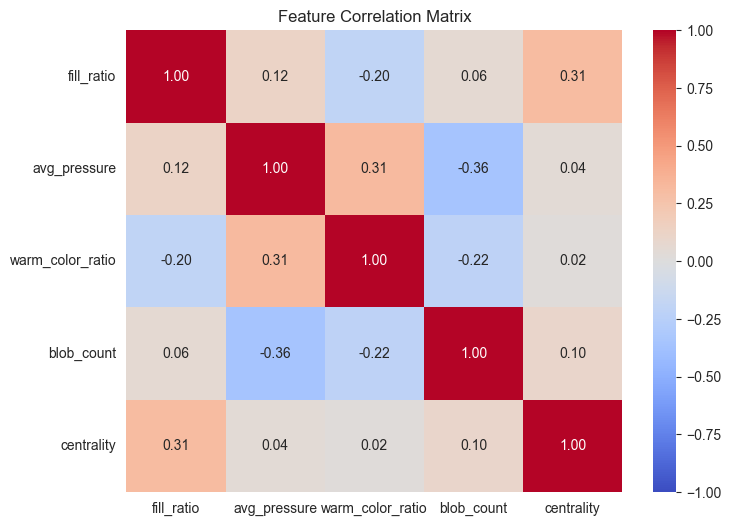

In [74]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

**Findings**

---

Fill Ratio & Centrality:
- Children who fill more space also tend to draw centrally, suggesting confidence or engagement

Pressure & Blob Count:
- High pressure - fewer blobs - bold, singular objects
- Low pressure - more blobs - detailed, careful drawings

Pressure & Warm Color:
- Warm colors co-occur with high pressure - expressive, emotionally intense drawings

Overall assessment:
- Features capture different aspects of drawing style: size, intensity, color, complexity, and position



## Exploring Pairwise Relationships

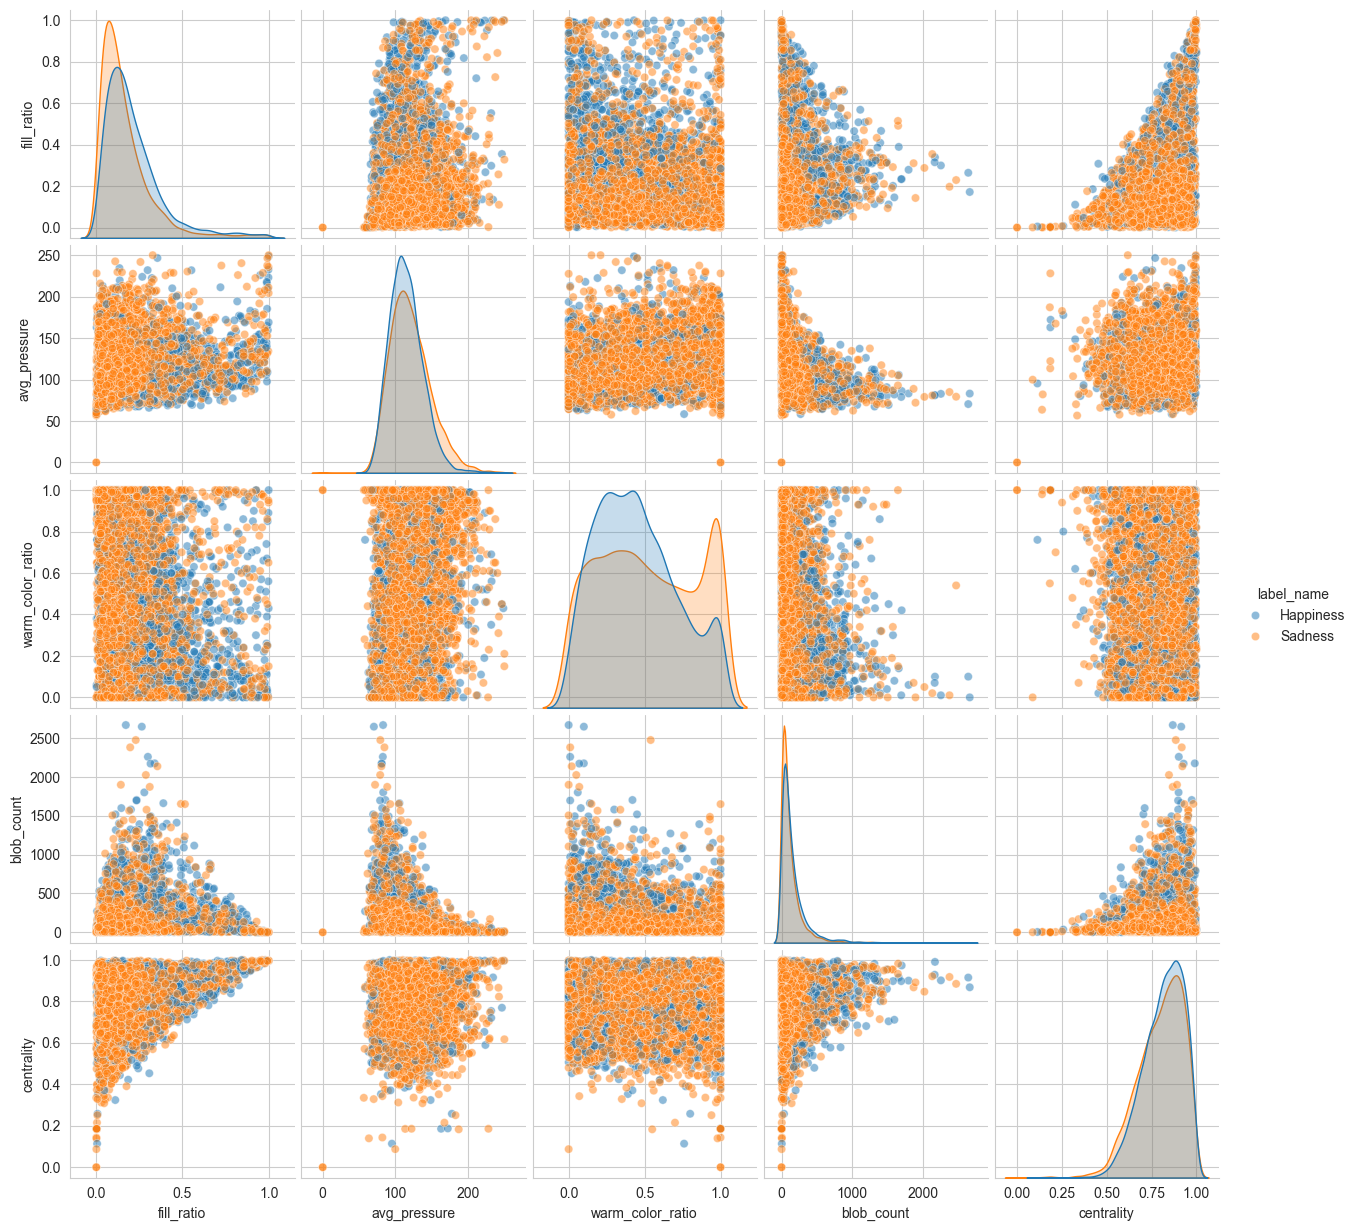

In [75]:
sns.pairplot(df, vars=['fill_ratio','avg_pressure','warm_color_ratio','blob_count','centrality'],
             hue='label_name', plot_kws={'alpha':0.5})
plt.show()

In [76]:
from scipy.stats import zscore
df_num = df[['fill_ratio','avg_pressure','warm_color_ratio','blob_count','centrality']]
df_z = df_num.apply(zscore)
outliers = (df_z.abs() > 3).any(axis=1)
print("Number of extreme outliers:", outliers.sum())

Number of extreme outliers: 671


In [77]:
from scipy.stats import ttest_ind
for feat in ['fill_ratio','avg_pressure','warm_color_ratio','blob_count','centrality']:
    happy_vals = df[df.label_name=='Happiness'][feat]
    sad_vals = df[df.label_name=='Sadness'][feat]
    stat, p = ttest_ind(happy_vals, sad_vals)
    print(f"{feat}: t-stat={stat:.2f}, p-value={p:.4f}")

fill_ratio: t-stat=15.01, p-value=0.0000
avg_pressure: t-stat=-12.02, p-value=0.0000
warm_color_ratio: t-stat=-12.47, p-value=0.0000
blob_count: t-stat=8.01, p-value=0.0000
centrality: t-stat=7.30, p-value=0.0000


All features significantly differ by emotional label.